In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iteration_function import mandelbrot_iterations

In [2]:
import iteration_function

print(iteration_function.__file__)

/cita/h/home-2/bhuang/Desktop/CTA200_2025/assignment_3/iteration_function.py


# Question 1

In [3]:
x_vals, y_vals, bound, diverge_iter = mandelbrot_iterations(n_pts=500)

print(x_vals, y_vals, bound, diverge_iter)

[-2.         -1.99198397 -1.98396794 -1.9759519  -1.96793587 -1.95991984
 -1.95190381 -1.94388778 -1.93587174 -1.92785571 -1.91983968 -1.91182365
 -1.90380762 -1.89579158 -1.88777555 -1.87975952 -1.87174349 -1.86372745
 -1.85571142 -1.84769539 -1.83967936 -1.83166333 -1.82364729 -1.81563126
 -1.80761523 -1.7995992  -1.79158317 -1.78356713 -1.7755511  -1.76753507
 -1.75951904 -1.75150301 -1.74348697 -1.73547094 -1.72745491 -1.71943888
 -1.71142285 -1.70340681 -1.69539078 -1.68737475 -1.67935872 -1.67134269
 -1.66332665 -1.65531062 -1.64729459 -1.63927856 -1.63126253 -1.62324649
 -1.61523046 -1.60721443 -1.5991984  -1.59118236 -1.58316633 -1.5751503
 -1.56713427 -1.55911824 -1.5511022  -1.54308617 -1.53507014 -1.52705411
 -1.51903808 -1.51102204 -1.50300601 -1.49498998 -1.48697395 -1.47895792
 -1.47094188 -1.46292585 -1.45490982 -1.44689379 -1.43887776 -1.43086172
 -1.42284569 -1.41482966 -1.40681363 -1.3987976  -1.39078156 -1.38276553
 -1.3747495  -1.36673347 -1.35871743 -1.3507014  -1.

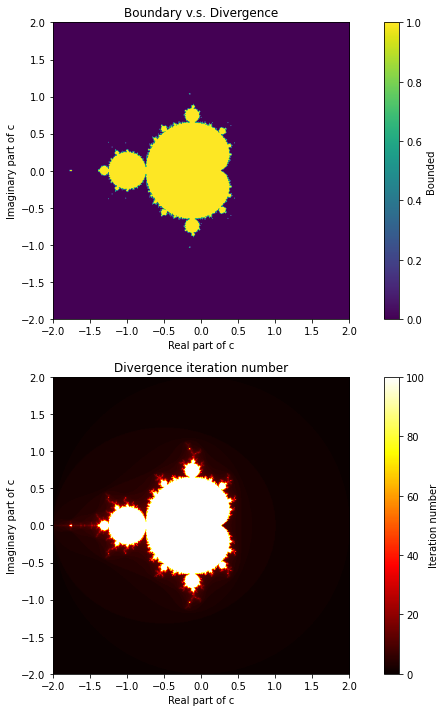

In [4]:
f, ax = plt.subplots(2, 1, figsize=(10,10))

im1 = ax[0].imshow(
    bound,
    extent=[-2, 2, -2, 2],
    origin="lower"
)

ax[0].set_xlabel("Real part of c")
ax[0].set_ylabel("Imaginary part of c")
ax[0].set_title("Boundary v.s. Divergence")
f.colorbar(im1, ax=ax[0], label="Bounded")

im2 = ax[1].imshow(
    diverge_iter,
    extent=[-2, 2, -2, 2],
    origin="lower",
    cmap="hot"
)
ax[1].set_xlabel("Real part of c")
ax[1].set_ylabel("Imaginary part of c")
ax[1].set_title("Divergence iteration number")
f.colorbar(im2, ax=ax[1], label="Iteration number")

plt.tight_layout()
plt.savefig("figure1_mandelbrot.pdf", bbox_inches="tight")
plt.show()

# Question 2

In [5]:
# Step 1
from lorenz import lorenz_equation

In [49]:
# Step 2
from scipy.integrate import solve_ivp

W0 = [0., 1., 0.]
t = 60
sigma = 10.
r = 28.
b = 8. / 3.

t_start_2 = 0
t_end_2 = 60

#sol = solve_ivp(
#    lorenz_equation,
#    t_span=(t_start_2,t_end_2),
#    y0=W0,
#    args=(sigma, r, b),
#    dense_output=True # Creat a function to evaluate at any time after solveing ODE
#)

sol = solve_ivp(
    lorenz_equation,
    t_span=(t_start_2,t_end_2),
    y0=W0,
    args=(sigma, r, b),
    dense_output=True
)

In [50]:
# Step 3, Figure 1 Reproduction:
dt = 0.01
t_start_3 = 0
t_end_3 = 30

t_interval = np.arange(t_start_3, t_end_3 + dt, dt)
W_3 = sol.sol(t_interval)

X = W_3[0]
Y = W_3[1]
Z = W_3[2]
N = t_interval/dt

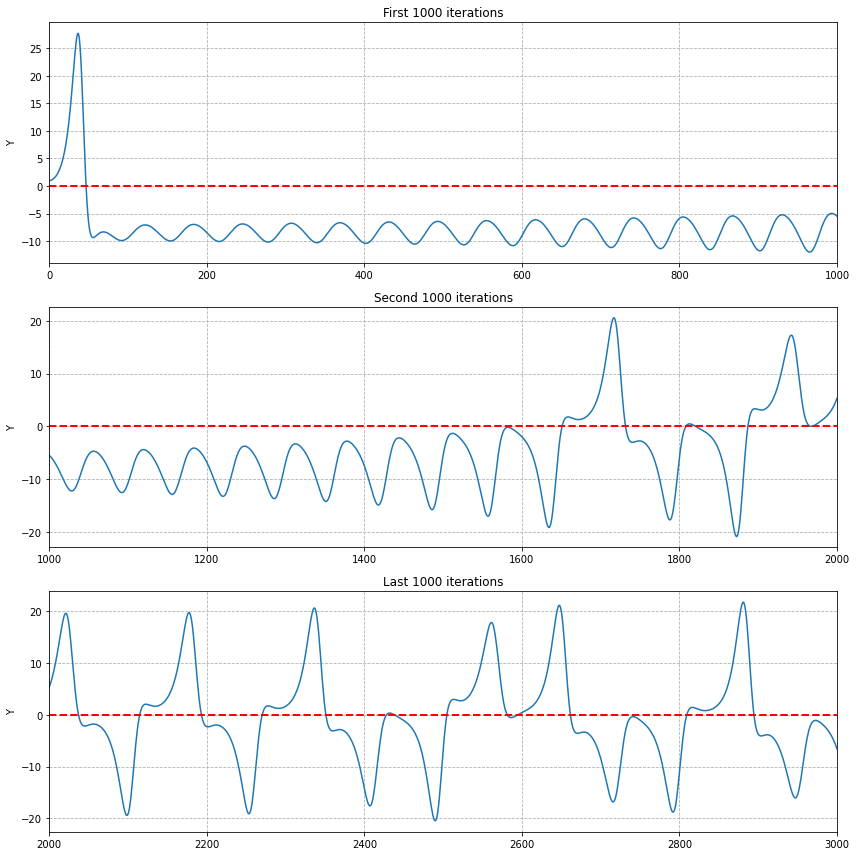

In [51]:
f, ax = plt.subplots(3, 1, figsize=(12,12))

# First 1000 iterations
mask1 = (N>=0) & (N<=1000)
ax[0].plot(N[mask1],Y[mask1])
ax[0].set_xlim(0, 1000)
ax[0].set_ylabel("Y")
ax[0].set_title("First 1000 iterations")

# Second 1000 iterations
mask2 = (N>=1000) & (N<=2000)
ax[1].plot(N[mask2],Y[mask2])
ax[1].set_xlim(1000, 2000)
ax[1].set_ylabel("Y")
ax[1].set_title("Second 1000 iterations")

# Last 1000 iterations
mask3 = (N>=2000) & (N<=3000)
ax[2].plot(N[mask3],Y[mask3])
ax[2].set_xlim(2000, 3000)
ax[2].set_ylabel("Y")
ax[2].set_title("Last 1000 iterations")

for a in ax:
    a.axhline(0, color='r', linestyle='--', linewidth=2)
    a.grid(linestyle='--')


plt.tight_layout()
plt.savefig("figure2_lorenz_fig1.pdf", bbox_inches="tight")
plt.show()

In [9]:
# Step 4

t_vals_4 = np.linspace(14, 19, 1000)
W_4 = sol.sol(t_vals_4)

X_4 = W_4[0]
Y_4 = W_4[1]
Z_4 = W_4[2]

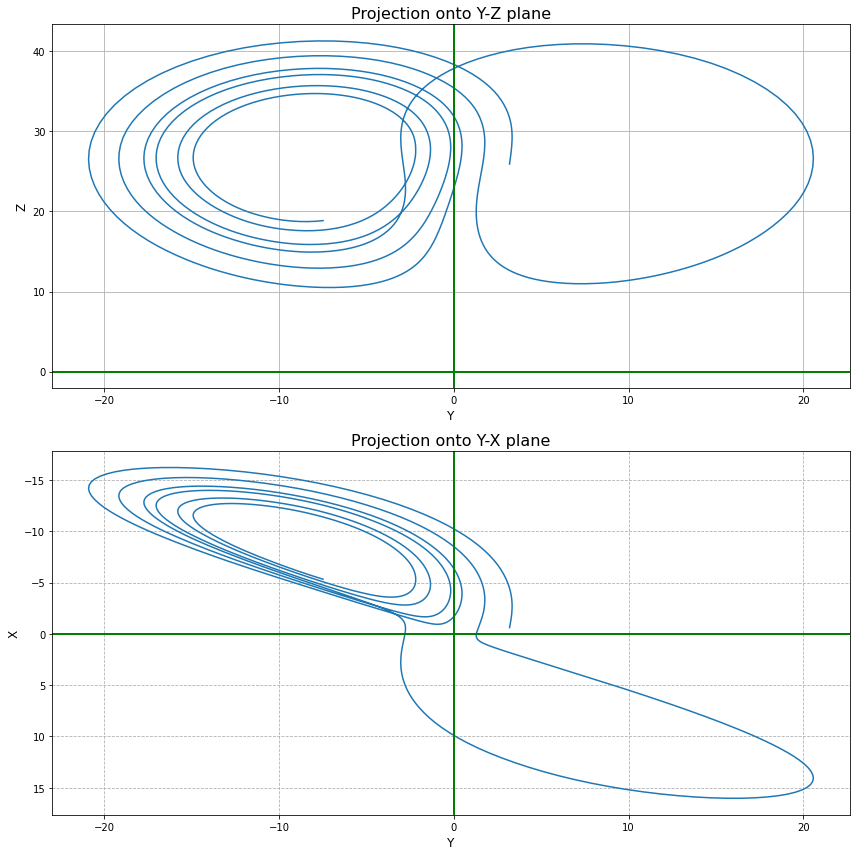

In [10]:
f, ax = plt.subplots(2,1, figsize=(12, 12))

ax[0].plot(Y_4, Z_4)
ax[0].axhline(0, color='green', linewidth=2)
ax[0].axvline(0, color='green', linewidth=2)
ax[0].set_xlabel("Y", fontsize='12')
ax[0].set_ylabel("Z", fontsize='12')
ax[0].set_title("Projection onto Y-Z plane", fontsize='16')
ax[0].grid()

ax[1].plot(Y_4, X_4)
ax[1].axhline(0, color='green', linewidth=2)
ax[1].axvline(0, color='green', linewidth=2)
ax[1].invert_yaxis()
ax[1].set_xlabel("Y", fontsize='12')
ax[1].set_ylabel("X", fontsize='12')
ax[1].set_title("Projection onto Y-X plane", fontsize='16')
ax[1].grid(linestyle='--')

plt.tight_layout()
plt.savefig("figure3_lorenz_fig2.pdf", bbox_inches="tight")
plt.show()

In [11]:
# Step 5
# use zip function to add 2 lists' elements

W0_new = [x+y for x, y in zip(W0, [0., 1.e-8, 0.])]

In [12]:
# Repeat step 2:
t_start_5 = 0
t_end_5 = 60

t_vals = np.linspace(t_start_5, t_end_5, 6000)

sol_og = solve_ivp(
    lorenz_equation,
    t_span=(t_start_5,t_end_5),
    y0=W0,
    t_eval=t_vals,
    args=(sigma, r, b)
)

sol_perturb = solve_ivp(
    lorenz_equation,
    t_span=(t_start_5,t_end_5),
    y0=W0_new,
    t_eval=t_vals,
    args=(sigma, r, b)
)

In [13]:
diff = sol_og.y - sol_perturb.y
distance = np.sqrt(
    diff[0]**2 + diff[1]**2 + diff[2]**2
)

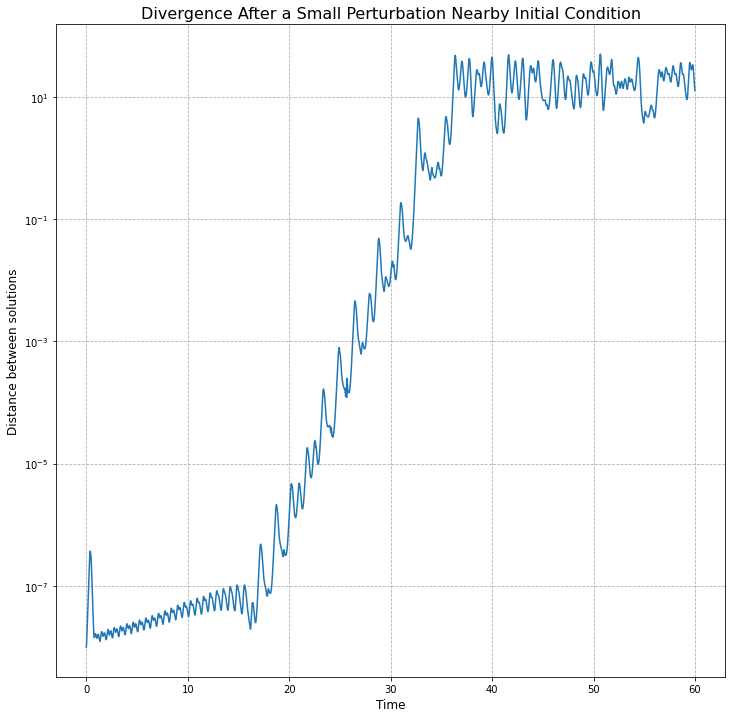

In [14]:
plt.figure(figsize=(12, 12))
plt.semilogy(t_vals, distance)
plt.xlabel("Time", fontsize='12')
plt.ylabel("Distance between solutions", fontsize='12')
plt.title("Divergence After a Small Perturbation Nearby Initial Condition", fontsize='16')

plt.grid(linestyle='--')
plt.savefig("figure4_perturbation.pdf", bbox_inches="tight")
plt.show()